# Lab 03 — Geometric Transformation, Tasks 3–10

These solutions follow the **Lab 03 Manual** hierarchy and the **Geometric Transformatio Notebook** style: NumPy matrices, OpenCV warping, and before/after plots. Coordinates are image coordinates: **x right, y down**. Points are column vectors, so the rightmost matrix acts first. The task sheet gives scenarios but no source images or measured points; the drawings and coordinates below are explicit, replaceable examples, not claimed task data.

Run cells from top to bottom. Requires `opencv-python`, `numpy`, and `matplotlib`. To use your own image, replace a generated image with `cv2.imread(path)` and measure the corresponding source and destination points in the same order.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

def show_pair(a, b, left, right, size=(11, 4)):
    fig, axes = plt.subplots(1, 2, figsize=size)
    for ax, im, title in zip(axes, (a, b), (left, right)):
        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        ax.set_title(title); ax.axis('off')
    plt.tight_layout()

def fit_affine(image, M, border=(255, 255, 255)):
    # Warp all four source corners into a canvas that cannot clip them.
    h, w = image.shape[:2]
    corners = np.float32([[0,0], [w-1,0], [w-1,h-1], [0,h-1]])
    moved = cv2.transform(corners[None], np.float32(M))[0]
    lo = np.floor(moved.min(axis=0)).astype(int)
    hi = np.ceil(moved.max(axis=0)).astype(int)
    F = np.array(M, dtype=np.float64).copy()
    F[:, 2] -= lo
    result = cv2.warpAffine(image, F, tuple((hi-lo+1).astype(int)),
                            borderValue=border)
    return result, F

def apply_points(H, points):
    return cv2.perspectiveTransform(np.float32(points)[None], np.float64(H))[0]


## Task 3 — Fast Train Barcode: undo horizontal shear

A right slant has `x' = x + k y`, `y' = y`, with 2×2 matrix `[[1,k],[0,1]]`. Its inverse is `[[1,-k],[0,1]]`. We demonstrate the correction on a deliberately sheared barcode. `fit_affine` adds only a canvas translation to keep all corners visible; it does not change the shear.


Shear 2x2:
 [[1.   0.35]
 [0.   1.  ]] 
Inverse 2x2:
 [[ 1.   -0.35]
 [ 0.    1.  ]]


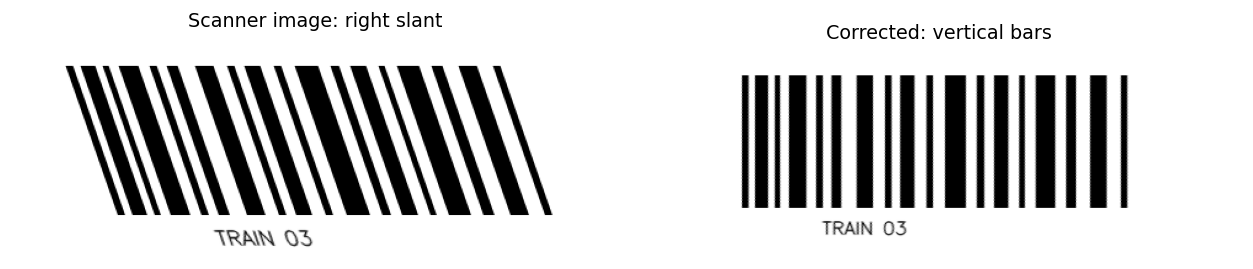

In [2]:
barcode = np.full((180, 430, 3), 255, np.uint8)
for x, width in [(35,5),(47,11),(65,4),(78,15),(103,5),(117,8),(140,14),
                 (166,5),(180,12),(204,5),(221,18),(250,6),(266,12),
                 (289,4),(304,17),(332,8),(354,14),(382,5)]:
    cv2.rectangle(barcode, (x, 25), (x+width, 145), (0,0,0), -1)
cv2.putText(barcode, 'TRAIN 03', (108, 170), cv2.FONT_HERSHEY_SIMPLEX,
            .55, (0,0,0), 1, cv2.LINE_AA)
k = 0.35
S = np.array([[1,k,0],[0,1,0]], np.float64)
slanted, S_canvas = fit_affine(barcode, S)
S_inverse_2x2 = np.array([[1,-k],[0,1]], np.float64)
corrected, _ = fit_affine(slanted, np.c_[S_inverse_2x2, [0,0]])
print('Shear 2x2:\n', S[:,:2], '\nInverse 2x2:\n', S_inverse_2x2)
show_pair(slanted, corrected, 'Scanner image: right slant', 'Corrected: vertical bars')


## Task 4 — Hidden Treasure Map: translation in homogeneous coordinates

The map is 150 pixels left and 80 pixels up. For column vectors `[x,y,1]ᵀ`, shift it back with `T = [[1,0,150],[0,1,80],[0,0,1]]`. The example retains the **full map layer** and shows a 500×330 viewport. Translation can reveal content outside that viewport; if pixels were already discarded from the only available image, no transform can reconstruct them.


Translation matrix:
 [[  1.   0. 150.]
 [  0.   1.  80.]
 [  0.   0.   1.]] 
X center in complete layer: (87,87) -> (237,167); corrected viewport position: (87,87).


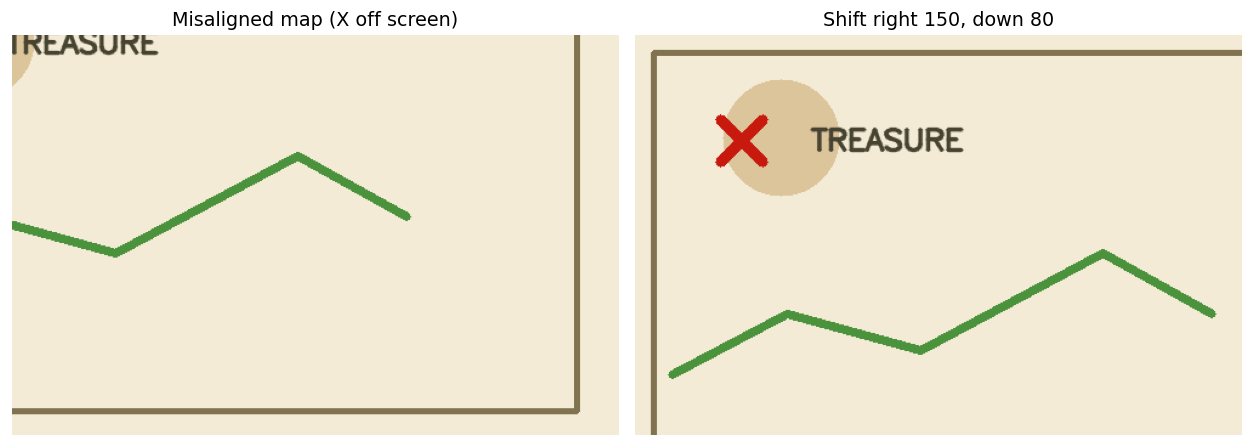

In [3]:
map_original = np.full((410, 650, 3), (213, 235, 243), np.uint8)
cv2.rectangle(map_original, (15,15), (615,390), (80,115,130), 3)
cv2.circle(map_original, (120,85), 48, (155,196,220), -1)
cv2.polylines(map_original, [np.array([(30,280),(125,230),(235,260),(385,180),(475,230)])],
              False, (61,146,75), 5)
cv2.line(map_original, (70,70), (105,105), (15,25,200), 7)
cv2.line(map_original, (105,70), (70,105), (15,25,200), 7)
cv2.putText(map_original, 'TREASURE', (145,95), cv2.FONT_HERSHEY_SIMPLEX,
            .8, (48,67,70), 2, cv2.LINE_AA)
# Viewport starts at (150,80) in the complete map layer, hiding the X.
misaligned = map_original[80:410, 150:650].copy()
T = np.array([[1,0,150],[0,1,80],[0,0,1]], np.float64)
shifted_full = cv2.warpAffine(map_original, T[:2], (800,490),
                              borderValue=(245,245,245))
restored = shifted_full[80:410, 150:650]
print('Translation matrix:\n', T,
      '\nX center in complete layer: (87,87) -> (237,167);'
      ' corrected viewport position: (87,87).')
show_pair(misaligned, restored, 'Misaligned map (X off screen)', 'Shift right 150, down 80')


## Task 5 — Robot's Assembly Line: rigid transform

Use one 3×3 matrix `M = T(target) R(-θ) T(-chip_center)`. The rotation has unit scale, so chip lengths and angles are preserved. The sample chip center is `(280,170)`, its angle is `30°` clockwise in screen coordinates, and the gripper target is `(440,170)`.


Rigid matrix:
 [[  0.866    0.5    112.5129]
 [ -0.5      0.866  162.7757]
 [  0.       0.       1.    ]] 
R^T R:
 [[1. 0.]
 [0. 1.]]


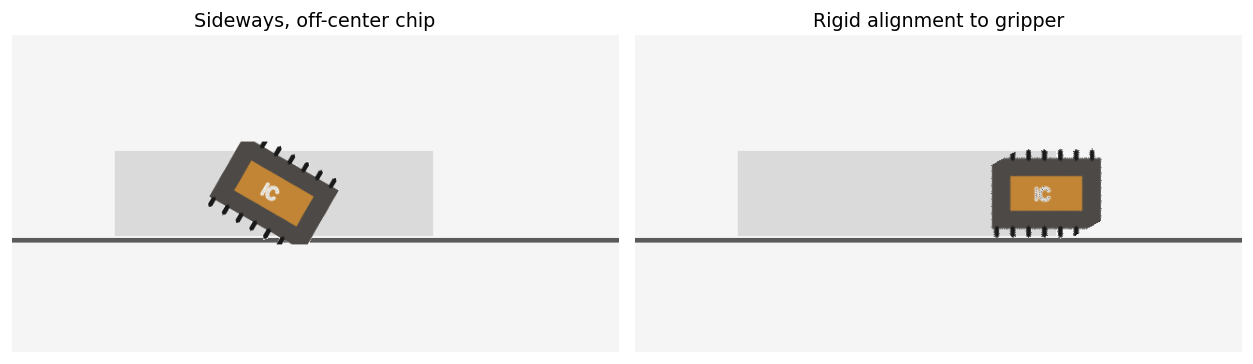

In [4]:
chip = np.full((340, 650, 3), 245, np.uint8)
cv2.rectangle(chip, (110,125), (450,215), (218,218,218), -1)
cv2.line(chip, (0,220), (649,220), (90,90,90), 4)
chip_patch = np.full((110,150,3), 255, np.uint8)
cv2.rectangle(chip_patch, (17,18), (133,92), (70,73,77), -1)
cv2.rectangle(chip_patch, (37,37), (113,73), (53,133,193), -1)
for px in range(22, 135, 17):
    cv2.line(chip_patch, (px,10), (px,18), (25,25,25), 3)
    cv2.line(chip_patch, (px,92), (px,100), (25,25,25), 3)
cv2.putText(chip_patch, 'IC', (62,62), cv2.FONT_HERSHEY_SIMPLEX,
            .6, (255,255,255), 2, cv2.LINE_AA)
angle = 30
source_center = np.array([280.,170.]); target_center = np.array([440.,170.])
rot_clockwise = cv2.getRotationMatrix2D((75,55), -angle, 1)
rotated = cv2.warpAffine(chip_patch, rot_clockwise, (150,110),
                         borderValue=(255,255,255))
mask = np.any(rotated < 250, axis=2)
background = chip.copy()
foreground = np.zeros_like(chip)
alpha = np.zeros(chip.shape[:2],np.uint8)
foreground[115:225,205:355][mask] = rotated[mask]
alpha[115:225,205:355][mask] = 255
chip[alpha>0] = foreground[alpha>0]
R = np.array([[np.cos(np.deg2rad(angle)), -np.sin(np.deg2rad(angle)), 0],
              [np.sin(np.deg2rad(angle)),  np.cos(np.deg2rad(angle)), 0],
              [0,0,1]], np.float64)
# OpenCV's negative image rotation makes the displayed chip 30 degrees clockwise;
# the inverse in screen coordinates is a -30 degree mathematical rotation.
R_undo = np.linalg.inv(R)
def translation(tx, ty):
    return np.array([[1,0,tx],[0,1,ty],[0,0,1]], np.float64)
M_rigid = translation(*target_center) @ R_undo @ translation(*source_center * -1)
aligned_foreground = cv2.warpAffine(foreground, M_rigid[:2], (650,340))
aligned_alpha = cv2.warpAffine(alpha, M_rigid[:2], (650,340), flags=cv2.INTER_NEAREST)
aligned = background.copy()
aligned[aligned_alpha>0] = aligned_foreground[aligned_alpha>0]
print('Rigid matrix:\n', M_rigid, '\nR^T R:\n', R_undo[:2,:2].T @ R_undo[:2,:2])
show_pair(chip, aligned, 'Sideways, off-center chip', 'Rigid alignment to gripper')


## Task 6 — Architect's Blueprint: similarity transform

One matrix performs translation, uniform scale, and rotation: `M = T(target) R(-θ) S(s) T(-source_center)`. The equal x/y factor `s` preserves angles and shape proportions. The sample uses `s=1.65`, a `-20°` screen-coordinate rotation, and a new center.


Similarity matrix:
 [[ 1.5505  0.5643 65.5488]
 [-0.5643  1.5505 17.927 ]
 [ 0.      0.      1.    ]] 
Lengths multiply by 1.65 and angles stay equal.


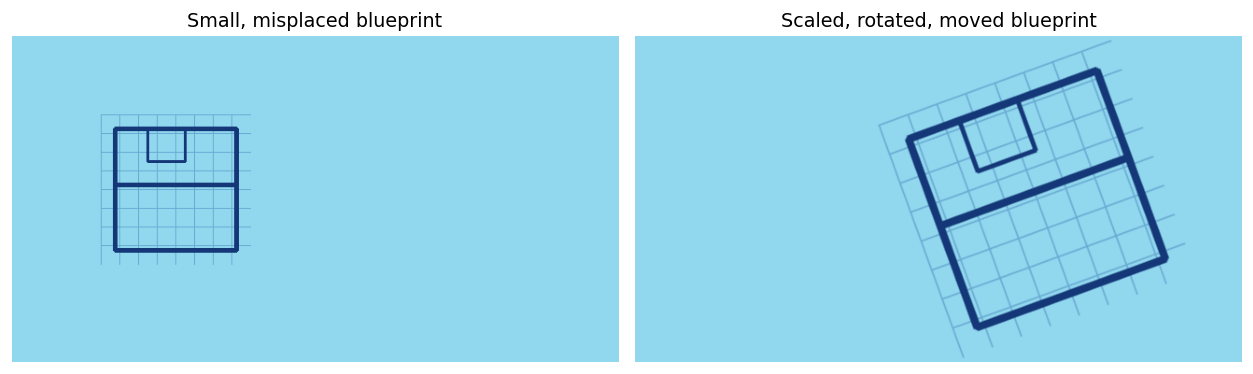

In [5]:
blueprint = np.full((350,650,3), (239,216,145), np.uint8)
for x in range(95,255,20):
    cv2.line(blueprint, (x,85), (x,245), (210,170,105), 1)
for y in range(85,245,20):
    cv2.line(blueprint, (95,y), (255,y), (210,170,105), 1)
cv2.rectangle(blueprint, (110,100), (240,230), (120,55,20), 3)
cv2.line(blueprint, (110,160), (240,160), (120,55,20), 3)
cv2.rectangle(blueprint, (145,100), (185,135), (120,55,20), 2)
source_bp = (175.,165.); target_bp = (430.,175.); scale = 1.65
theta = np.deg2rad(-20)
Rot = np.array([[np.cos(theta),-np.sin(theta),0],
                [np.sin(theta), np.cos(theta),0],[0,0,1]])
Scale = np.diag([scale,scale,1.])
M_similarity = translation(*target_bp) @ Rot @ Scale @ translation(-source_bp[0],-source_bp[1])
blueprint_fixed = cv2.warpAffine(blueprint, M_similarity[:2], (650,350),
                                 borderValue=(239,216,145))
print('Similarity matrix:\n', M_similarity,
      '\nLengths multiply by', scale, 'and angles stay equal.')
show_pair(blueprint, blueprint_fixed, 'Small, misplaced blueprint', 'Scaled, rotated, moved blueprint')


## Task 7 — Glitched Image: solve all six affine parameters

For each correspondence `(x,y) → (u,v)`, the equations are `u=ax+by+tx` and `v=cx+dy+ty`. Three non-collinear pairs give six equations for `[a,b,tx,c,d,ty]`. The sample landmarks are the centers of three colored dots. We solve the system directly with `np.linalg.solve`, then apply the matrix once.


Source landmarks:
 [[104.6   88.2 ]
 [365.    65.8 ]
 [154.55 238.4 ]] 
Destination landmarks:
 [[ 80.  80.]
 [360.  80.]
 [100. 245.]] 
Solved [a,b,tx,c,d,ty]:
 [  1.0565  -0.2182 -11.2655   0.0919   1.068  -23.8057] 
Landmark residuals: [0. 0. 0.]


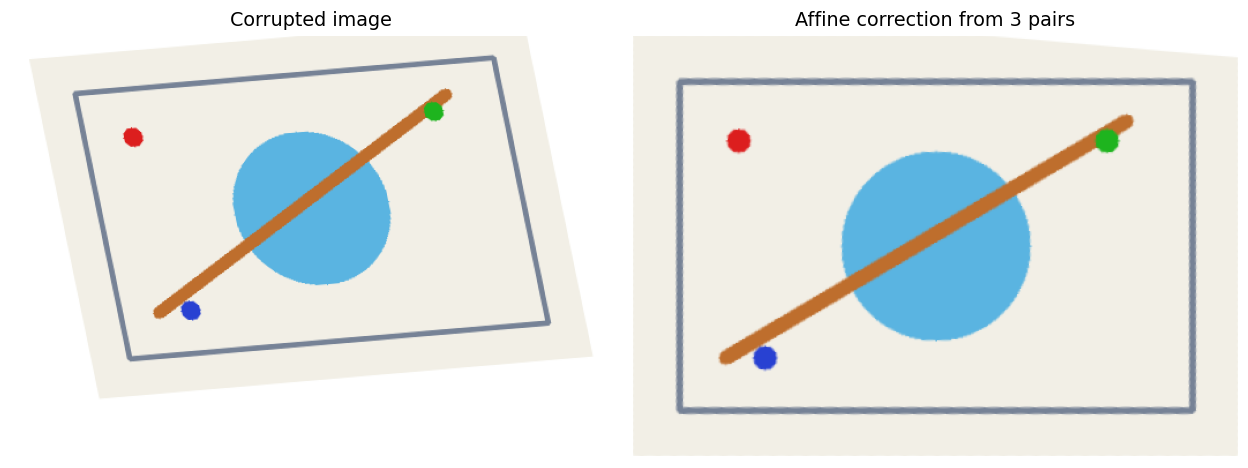

In [6]:
photo = np.full((320,460,3), (230,239,242), np.uint8)
cv2.rectangle(photo, (35,35), (425,285), (150,130,118), 3)
cv2.circle(photo, (230,160), 72, (225,180,90), -1)
cv2.line(photo, (70,245), (375,65), (45,110,190), 9)
landmarks_dst = np.float64([[80,80],[360,80],[100,245]])
for p, color in zip(landmarks_dst, [(30,30,220),(30,180,30),(210,65,40)]):
    cv2.circle(photo, tuple(p.astype(int)), 9, color, -1)
A_corrupt = np.array([[.93,.19,15],[-.08,.92,21]], np.float64)
glitched = cv2.warpAffine(photo, A_corrupt, (520,365), borderValue=(255,255,255))
landmarks_src = cv2.transform(landmarks_dst.astype(np.float32)[None],
                              A_corrupt.astype(np.float32))[0].astype(float)
system = []; rhs = []
for (x,y),(u,v) in zip(landmarks_src, landmarks_dst):
    system.extend([[x,y,1,0,0,0],[0,0,0,x,y,1]])
    rhs.extend([u,v])
params = np.linalg.solve(np.array(system), np.array(rhs))
M_affine = params.reshape(2,3)
recovered = cv2.warpAffine(glitched, M_affine, (460,320),
                           borderValue=(255,255,255))
print('Source landmarks:\n', landmarks_src,
      '\nDestination landmarks:\n', landmarks_dst,
      '\nSolved [a,b,tx,c,d,ty]:\n', params,
      '\nLandmark residuals:', np.linalg.norm(cv2.transform(
          landmarks_src.astype(np.float32)[None], M_affine.astype(np.float32))[0]
          - landmarks_dst, axis=1))
show_pair(glitched, recovered, 'Corrupted image', 'Affine correction from 3 pairs')


## Task 8 — Sidewalk Illusion: four-point perspective rectification

Order corners consistently as top-left, top-right, bottom-right, bottom-left. A homography maps the four observed corners to a square. OpenCV computes the 3×3 matrix; `warpPerspective` divides by the homogeneous third coordinate. The sample creates a tilted sidewalk view and recovers the square art.


Rectifying homography:
 [[   3.0256    1.4238 -687.878 ]
 [   0.        4.8647 -437.8214]
 [   0.        0.0091    1.    ]] 
Corner residuals: [0. 0. 0. 0.]


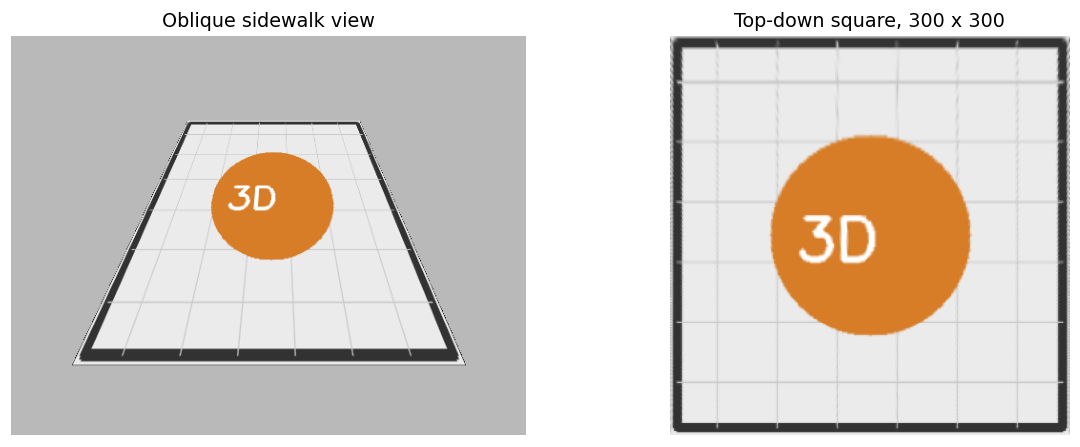

In [7]:
art = np.full((300,300,3), (235,235,235), np.uint8)
cv2.rectangle(art, (5,5), (294,294), (50,50,50), 5)
for t in range(35,300,45):
    cv2.line(art,(t,5),(t,294),(200,200,200),1)
    cv2.line(art,(5,t),(294,t),(200,200,200),1)
cv2.circle(art,(150,150),75,(40,125,215),-1)
cv2.putText(art,'3D',(94,168),cv2.FONT_HERSHEY_SIMPLEX,1.5,(255,255,255),4)
art_corners = np.float32([[0,0],[299,0],[299,299],[0,299]])
seen_corners = np.float32([[185,90],[365,90],[475,345],[65,345]])
H_view = cv2.getPerspectiveTransform(art_corners, seen_corners)
sidewalk = np.full((420,540,3), (185,185,185), np.uint8)
warped_art = cv2.warpPerspective(art,H_view,(540,420))
mask = cv2.warpPerspective(np.full((300,300),255,np.uint8),H_view,(540,420))
sidewalk[mask>0] = warped_art[mask>0]
H_rectify = cv2.getPerspectiveTransform(seen_corners, art_corners)
top_down = cv2.warpPerspective(sidewalk,H_rectify,(300,300))
print('Rectifying homography:\n', H_rectify,
      '\nCorner residuals:', np.linalg.norm(apply_points(H_rectify,seen_corners)-art_corners,axis=1))
show_pair(sidewalk,top_down,'Oblique sidewalk view','Top-down square, 300 x 300')


## Task 9 — Stadium Panorama: project camera 2 into camera 1

Four matching, non-collinear points in the overlap determine `H(2→1)`. The two sample camera views are made from a common stadium scene so their matches are known exactly. Camera 2 also has a mild perspective tilt. After estimating `H`, we transform both images into a canvas that contains all corners and feather-blend valid pixels in their overlap. Real photos need genuinely corresponding points on the same scene; four points work only when one homography adequately models the view.


Camera 2 -> camera 1 homography:
 [[  1.1919   0.1402 325.9672]
 [  0.0282   1.1481 -17.7856]
 [  0.0001   0.0002   1.    ]] 
Matching-point residuals: [0. 0. 0. 0.] 
Panorama size: (1001, 352)


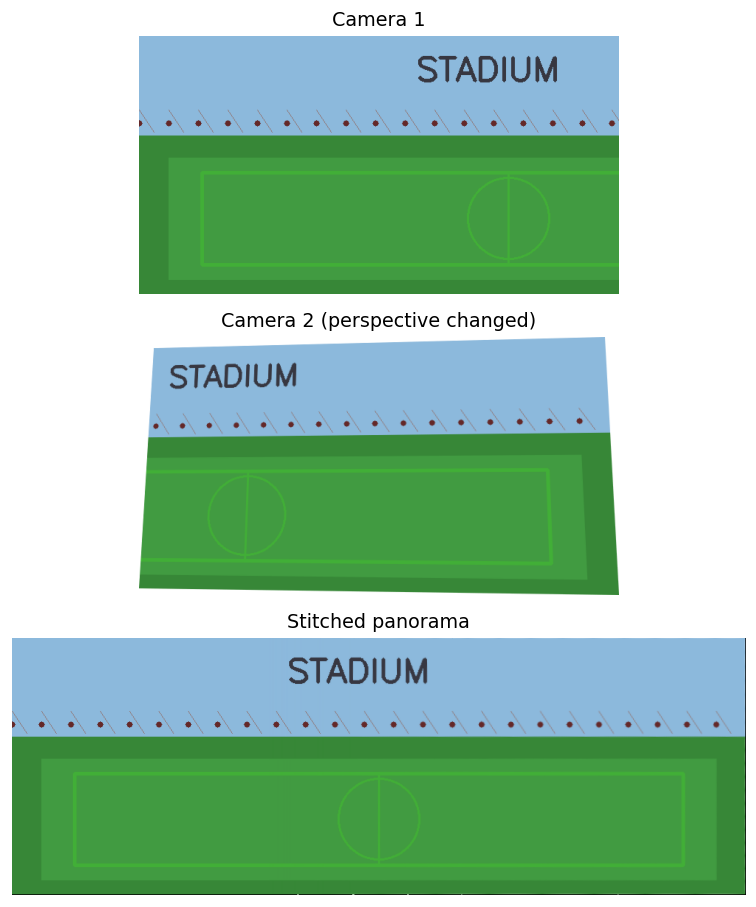

In [8]:
scene = np.full((350,1000,3), (220,185,140), np.uint8)
cv2.rectangle(scene,(0,135),(999,349),(55,135,55),-1)
cv2.rectangle(scene,(40,165),(960,330),(65,155,65),-1)
cv2.rectangle(scene,(85,185),(915,310),(55,175,65),3)
cv2.line(scene,(500,185),(500,310),(55,175,65),2)
cv2.circle(scene,(500,247),55,(55,175,65),2)
for x in range(0,1000,40):
    cv2.circle(scene,(x,118),4,(40,40,100),-1)
    cv2.line(scene,(x,100),(x+20,130),(120,120,145),1)
cv2.putText(scene,'STADIUM', (375,60),cv2.FONT_HERSHEY_SIMPLEX,1.5,(65,55,55),3)
camera1 = scene[:,:650].copy()
right_crop = scene[:,350:].copy()
right_corners = np.float32([[0,0],[649,0],[649,349],[0,349]])
camera2_corners = np.float32([[20,15],[630,0],[649,349],[0,340]])
Q = cv2.getPerspectiveTransform(right_corners,camera2_corners)
camera2 = cv2.warpPerspective(right_crop,Q,(650,350),borderValue=(255,255,255))
in_right = np.float32([[55,65],[255,65],[255,280],[55,280]])
points2 = apply_points(Q,in_right).astype(np.float32)
points1 = in_right + np.float32([350,0])
H21 = cv2.getPerspectiveTransform(points2,points1)
corners2_in_1 = apply_points(H21,camera2_corners)
all_corners = np.vstack([np.float32([[0,0],[649,0],[649,349],[0,349]]),corners2_in_1])
lo = np.floor(all_corners.min(axis=0)).astype(int)
hi = np.ceil(all_corners.max(axis=0)).astype(int)
shift = translation(-lo[0],-lo[1])
size = tuple((hi-lo+1).astype(int))
W1 = cv2.warpPerspective(camera1,shift,size).astype(float)
W2 = cv2.warpPerspective(camera2,shift@H21,size).astype(float)
V1 = cv2.warpPerspective(np.ones(camera1.shape[:2],np.uint8),shift,size).astype(float)
valid2_camera = cv2.warpPerspective(np.ones(right_crop.shape[:2],np.uint8),
                                    Q,(650,350))
V2 = cv2.warpPerspective(valid2_camera,shift@H21,size).astype(float)
blend = np.clip((np.arange(size[0],dtype=float)-(350-lo[0]))/300,0,1)[None,:]
blend = np.broadcast_to(blend,V1.shape)
weight1 = np.where(V2>0,V1*(1-blend),V1)
weight2 = np.where(V1>0,V2*blend,V2)
panorama = np.uint8(np.clip((W1*weight1[...,None]+W2*weight2[...,None]) /
                            np.maximum(weight1+weight2,1e-9)[...,None],0,255))
print('Camera 2 -> camera 1 homography:\n',H21,
      '\nMatching-point residuals:',np.linalg.norm(apply_points(H21,points2)-points1,axis=1),
      '\nPanorama size:',size)
fig,axes=plt.subplots(3,1,figsize=(12,8))
for ax,im,title in zip(axes,(camera1,camera2,panorama),
                       ('Camera 1','Camera 2 (perspective changed)','Stitched panorama')):
    ax.imshow(cv2.cvtColor(im,cv2.COLOR_BGR2RGB)); ax.set_title(title); ax.axis('off')
plt.tight_layout()


## Task 10 — Master Forger: scale, rigid move, then projective warp

The composition is `M = H · T · R · S` in column-vector notation. First shrink the painting uniformly (`S`). Next rotate and move the scaled painting near the frame (`T·R`). Finally compute `H` from those staged four corners to the frame's four inner corners. Warp the original painting **once** with `M` to avoid repeated resampling. A mask limits compositing to the frame opening.


Scale S:
 [[0.68 0.   0.  ]
 [0.   0.68 0.  ]
 [0.   0.   1.  ]] 
Rigid T R:
 [[  0.9903  -0.1392 284.34  ]
 [  0.1392   0.9903 146.94  ]
 [  0.       0.       1.    ]] 
Projective H:
 [[  1.1376   0.0117 -27.9281]
 [ -0.0863   1.4072 -76.4376]
 [ -0.       0.0001   1.    ]] 
Combined matrix:
 [[  0.7671  -0.0998 297.2578]
 [  0.0751   0.9558 105.8036]
 [ -0.       0.0001   1.0077]] 
Final corner residuals: [0. 0. 0. 0.]


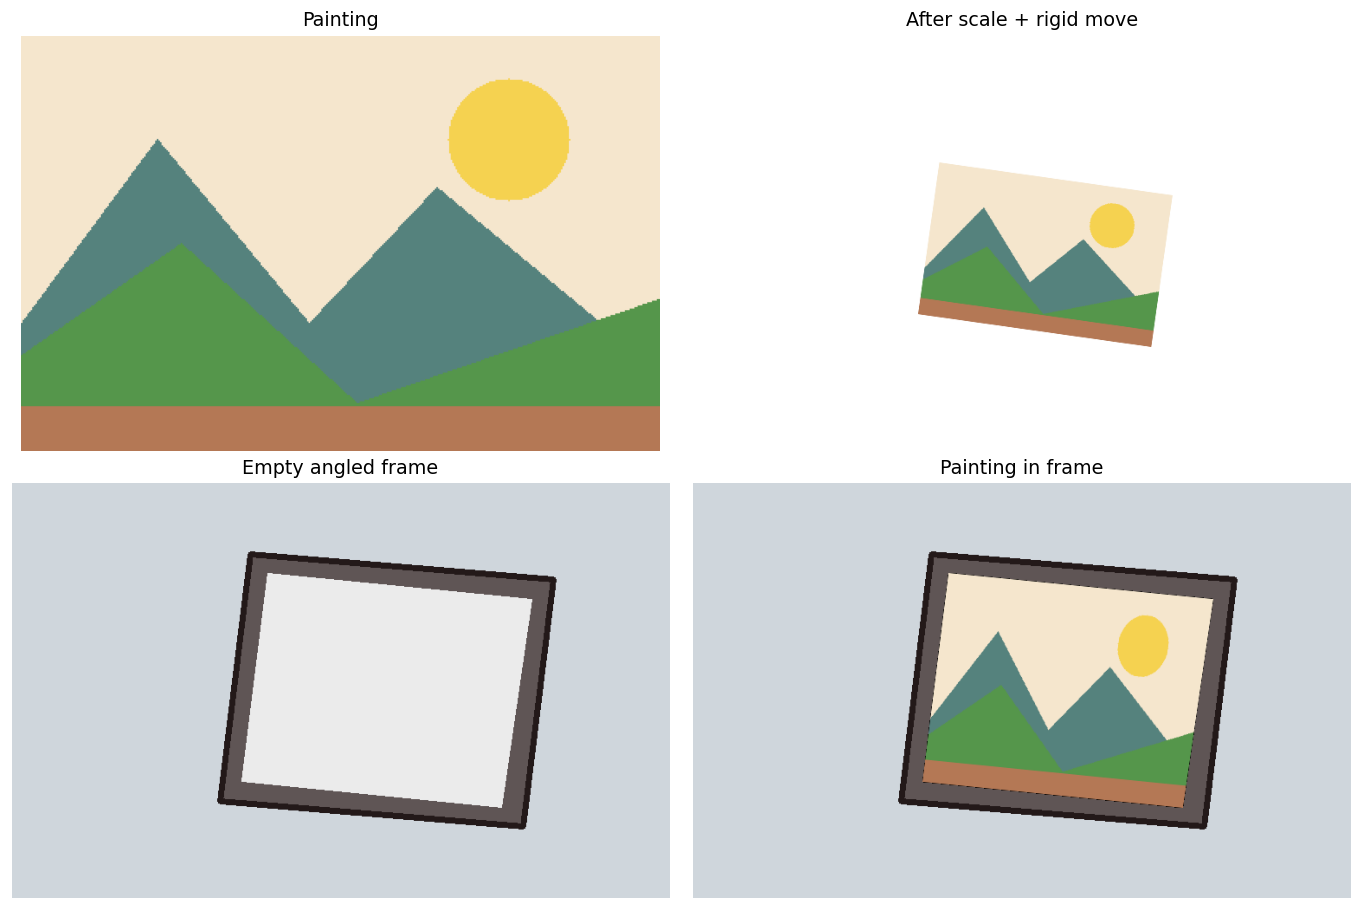

In [9]:
painting = np.full((260,400,3),(205,230,245),np.uint8)
cv2.circle(painting,(305,65),38,(80,210,245),-1)
mountains=np.array([[0,180],[85,65],[180,180],[260,95],[400,210],[400,259],[0,259]])
cv2.fillPoly(painting,[mountains],(125,130,85))
cv2.fillPoly(painting,[np.array([[0,200],[100,130],[210,230],[400,165],[400,259],[0,259]])],(75,150,85))
cv2.rectangle(painting,(0,232),(399,259),(85,120,180),-1)
wall=np.full((480,760,3),(220,214,207),np.uint8)
inner=np.float32([[295,105],[600,135],[565,375],[265,345]])
outer=np.int32([[275,83],[625,112],[590,397],[240,368]])
cv2.fillConvexPoly(wall,outer,(85,85,95))
cv2.fillConvexPoly(wall,inner.astype(np.int32),(235,235,235))
cv2.polylines(wall,[outer],True,(25,25,35),5)
source=np.float32([[0,0],[399,0],[399,259],[0,259]])
S10=np.diag([.68,.68,1.])
phi=np.deg2rad(8)
R10=np.array([[np.cos(phi),-np.sin(phi),0],
              [np.sin(phi), np.cos(phi),0],[0,0,1.]])
scaled_center=np.array([399*.68/2,259*.68/2])
T10=translation(420-scaled_center[0],235-scaled_center[1])
rigid10=T10@R10
stage10=rigid10@S10
staged_corners=apply_points(stage10,source).astype(np.float32)
H10=cv2.getPerspectiveTransform(staged_corners,inner)
M10=H10@stage10
staged=cv2.warpPerspective(painting,stage10,(760,480),borderValue=(255,255,255))
projected=cv2.warpPerspective(painting,M10,(760,480))
paint_mask=cv2.warpPerspective(np.full(painting.shape[:2],255,np.uint8),M10,(760,480))
completed=wall.copy(); completed[paint_mask>0]=projected[paint_mask>0]
cv2.polylines(completed,[outer],True,(25,25,35),5)
print('Scale S:\n',S10,'\nRigid T R:\n',rigid10,
      '\nProjective H:\n',H10,'\nCombined matrix:\n',M10,
      '\nFinal corner residuals:',np.linalg.norm(apply_points(M10,source)-inner,axis=1))
fig,axes=plt.subplots(2,2,figsize=(12,8))
for ax,im,title in zip(axes.flat,(painting,staged,wall,completed),
                       ('Painting','After scale + rigid move','Empty angled frame','Painting in frame')):
    ax.imshow(cv2.cvtColor(im,cv2.COLOR_BGR2RGB)); ax.set_title(title); ax.axis('off')
plt.tight_layout()


## Replacing the sample inputs

- **Task 3:** Measure the scanner's rightward shift over a vertical distance: `k = Δx/Δy`; then use `-k` to undo it.
- **Tasks 4–6:** Change offsets, centers, angles, and scale to match the measured object and target.
- **Task 7:** Replace both `landmarks_src` and `landmarks_dst` with three matching, non-collinear coordinates.
- **Task 8:** Replace `seen_corners` in clockwise order starting at top-left; choose a square output size.
- **Task 9:** Replace `camera1`, `camera2`, `points1`, and `points2`; order each pair identically. More than four noisy matches should use `cv2.findHomography(..., cv2.RANSAC)`.
- **Task 10:** Replace `painting`, `wall`, and `inner` with your image, wall image, and the four inner frame corners in matching order. Recompute `source` from the painting dimensions.

The notebook's plotted outputs were executed and embedded. Synthetic examples demonstrate the mathematics; a result for an actual photograph depends on its supplied pixels and measured correspondences.
